## Product-type 1 <머신러닝>
- XGBoost
- LightGBM

In [20]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 기본
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display
import warnings
import platform

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 모델 학습 및 평가 지표
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score, # PR-AUC 수치 계산
    PrecisionRecallDisplay # PR Curve 시각화
)

# XGBoost / LightGBM
import xgboost as xgb
from xgboost import XGBClassifier

import lightgbm as lgb
from lightgbm import LGBMClassifier

# SHAP
import shap

# 모델링한 최종 머신러닝 모델을 저장하는 라이브러리
import joblib
import os

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# matplotlib 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 고정
np.random.seed(42)

print("=" * 60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("=" * 60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


---
---
### **1. 데이터 로드**

In [21]:
# 1. 전체 데이터 호출
df_original_1 = pd.read_csv('../data/ML_modeling_data_product-1.csv')

# 2. 타겟(y) 컬럼과 제외할 컬럼 정의
target_cols = "is_defect"
drop_cols = [
    target_cols,
    "coolant_pressure",
    "spray_1_time",
    "velocity_1",
    "velocity_3",
    "shot_key"
]

# 3. 피쳐(X)와 타겟(y) 분리
X = df_original_1.drop(columns=drop_cols)
y = df_original_1[target_cols]

print("=" * 30)
print(f"피쳐(X)의 크기 : {X.shape}")
print(f"타겟(y)의 크기 : {y.shape}")
print("=" * 30)

피쳐(X)의 크기 : (4207, 16)
타겟(y)의 크기 : (4207,)


---
### **2. Train/Test 데이터 분리 및 저장**
- Train : Test = 8 : 2
- 프로젝트 진행 중, 코드를 실행하는 환경에 따라 모델의 성능이 다르게 평가되는 것을
방지하기 위하여 각각의 데이터를 csv 형식으로 저장함

In [22]:
# 1. Train/Test 데이터 분리 (80:20)
X_train_p1, X_test_p1, y_train_p1, y_test_p1 = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y, # 불량 비율 유지
    shuffle=True
)

print("=" * 30)
print(f"Train 샘플 수(X): {len(X_train_p1):,}개")
print(f"Train 샘플 수(y): {len(y_train_p1):,}개")
print('-' * 30)
print(f"Test  샘플 수(X): {len(X_test_p1):,}개")
print(f"Test  샘플 수(y): {len(y_test_p1):,}개")
print('-' * 30)
print(f"Train 데이터의 불량률: {y_train_p1.mean() * 100:.2f}%")
print(f"Test 데이터의 불량률: {y_test_p1.mean() * 100:.2f}%")
print("=" * 30)

Train 샘플 수(X): 3,365개
Train 샘플 수(y): 3,365개
------------------------------
Test  샘플 수(X): 842개
Test  샘플 수(y): 842개
------------------------------
Train 데이터의 불량률: 17.56%
Test 데이터의 불량률: 17.58%


In [23]:
# 2. csv 형식으로 Train/Test 데이터 저장
df_train_p1 = pd.concat([X_train_p1, y_train_p1], axis=1) # aixs=1 : 컬럼을 기준으로 병합
df_test_p1  = pd.concat([X_test_p1,  y_test_p1],  axis=1)

df_train_p1.to_csv('../data/train_data_product-1.csv', index=False)
df_test_p1.to_csv('../data/test_data_product-1.csv',   index=False)

print("Train Data 저장 완료")
print("Test Data 저장 완료")

Train Data 저장 완료
Test Data 저장 완료


---
### **3. 가중치 및 모델의 성능 평가 함수 정의**

#### 3.1 클래스 불균형 문제를 해결하기 위한 가중치 계산
- 소수 클래스인 불량(1)에 가중치를 부여하고자 함

In [24]:
# 소수 클래스인 불량에 부여할 가중치 계산

cnt_of_normal = (y_train_p1 == 0).sum() # 정상 제품(0)의 개수
cnt_of_defect = (y_train_p1 == 1).sum() # 불량 제품(1)의 개수
weights = cnt_of_normal / cnt_of_defect

print("=" * 30)
print(f"정상(0) 샘플 수: {cnt_of_normal:,}개")
print(f"불량(1) 샘플 수: {cnt_of_defect:,}개")
print(f"scale_pos_weight: {weights:.4f}")
print("=" * 30)

정상(0) 샘플 수: 2,774개
불량(1) 샘플 수: 591개
scale_pos_weight: 4.6937


#### 3.2 Stratified K-Fold 설정
- 교차검증 설정
- 불균형 분포를 가진 데이터 비율을 맞추기 위해 지정
- 해당 방법을 사용하면, 데이터를 분할할 때 불균형 클래스의 비율을 원본 데이터셋과 유사하게 맞춰준다고 함

In [25]:
cv = StratifiedKFold(
    n_splits=5,       # 5개의 Fold로 분할
    shuffle=True,     # 분할하기 전 데이터 섞기
    random_state=42   # 재현성 보장
)

#### 3.3 모델의 성능 평가 함수 정의
- 목적 : 기초 / 성능 최적화 모델에 모두 적용할 수 있는 평가 함수 제작
- 평가지표: 혼동행렬 / Classification Report / PR-AUC
- 함수 인자 설명
    - model: 평가할 모델
    - X_test: 테스트 피쳐
    - y_test: 테스트 타겟
    - graph_title: 그래프 제목에 표시할 이름

In [26]:
def evaluate_model(model, X_test, y_test, graph_title):
    
    # 1. 예측
    y_pred = model.predict(X_test) # 클래스 예측 (0 또는 1) - 확률이 0.5 이상일 때 불량으로 예측
    y_prob = model.predict_proba(X_test)[:, 1] # 불량(1)일 확률만 출력

    # 2. PR-AUC(곡선 아래 면적) 계산
    pr_auc   = average_precision_score(y_test, y_prob) # PR-AUC 곡선 아래 면적 계산
    baseline = y_test.mean() # 테스트 데이터의 불량률 -> PR-AUC 곡선의 기준선

    # 3. Precision / Recall / F1-Score 출력
    print(f"\n{'=' * 55}")
    print(f"  {graph_title}")
    print(f"{'=' * 55}")
    print(f"\nPR-AUC: {pr_auc:.4f}   (Random Baseline: {baseline:.4f})")
    print(f"\nClassification Report")
    print(classification_report(y_test, y_pred, target_names=["정상(0)", "불량(1)"]))

    # 4. 시각화
    # fig는 안 쓸거라서 _로 처리
    # facecolor='none'의 의미: 배경을 투명하게 
    _, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='none') 

    # 5. 혼동행렬
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
        xticklabels=["정상(0)", "불량(1)"],
        yticklabels=["정상(0)", "불량(1)"],
        annot_kws={"size": 16}
    )
    # 5-1. 각 셀에 TN / FP / FN(위험) / TP 표시
    cell_labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            axes[0].text(j + 0.5, i + 0.78, cell_labels[i][j],
                        ha="center", va="center",
                        color="gray", fontsize=9)
    axes[0].set_title(f"{graph_title}\nConfusion Matrix", fontsize=13)
    axes[0].set_ylabel("실제값", fontsize=11)
    axes[0].set_xlabel("예측값", fontsize=11)

    # 6. PR Curve
    disp = PrecisionRecallDisplay.from_predictions(
    y_test, y_prob,
    name=f"{graph_title} (PR-AUC = {pr_auc:.4f})",
    ax=axes[1],
    color="steelblue"
    )
    # 자동으로 표시되는 Average Precision(AP)를 덮어씌워서 숨김
    disp.line_.set_label(f"{graph_title} (PR-AUC = {pr_auc:.4f})")

    # 6-1. PR Curve 기준선 
    axes[1].axhline(
        y=baseline, color="gray", linestyle="--", linewidth=1.2,
        label=f"Random Baseline ({baseline:.4f})"
    )
    axes[1].set_title(f"{graph_title}\nPR Curve", fontsize=13)
    axes[1].legend(
    fontsize=10,
    bbox_to_anchor=(0.5, -0.15),  # 그래프 아래쪽으로 범례 이동
    loc='upper center',            # 기준점 설정
    ncol=1                         # 범례를 1열로 표시
    )

    plt.tight_layout()
    plt.show()

---
### **4. 머신러닝 모델 개발 (XGBoost)**

#### 4.1 XGBoost - 기초
- 학습율 0.1를 제외하고, XGBoost의 기본 파라미터를 사용해 baseline 확인

In [27]:
# 1. GridSearch 전 기준점(Baseline) 성능을 확인
xgb_base_p1 = XGBClassifier(
    learning_rate=0.1,
    scale_pos_weight=weights,  # 클래스 불균형을 보정하기 위한 가중치 (정상/불량 = 4.6937)
    eval_metric="logloss",     # 내부 평가 기준 (이진 분류 표준)
    random_state=42,
    n_jobs=-1                  # 모든 CPU 코어 사용
)
# 기본 파라미터 사용
    # n_estimators = 100
    # max_depth = 6
    # subsample = 1.0
    

# 2. Train 데이터로 학습
xgb_base_p1.fit(X_train_p1, y_train_p1)

print("=" * 30)
print("XGBoost Base 학습 완료!")
print("=" * 30)

XGBoost Base 학습 완료!



  XGBoost 기초 모델링 - Product 1

PR-AUC: 0.5596   (Random Baseline: 0.1758)

Classification Report
              precision    recall  f1-score   support

       정상(0)       0.95      0.80      0.87       694
       불량(1)       0.46      0.79      0.58       148

    accuracy                           0.80       842
   macro avg       0.70      0.80      0.73       842
weighted avg       0.86      0.80      0.82       842



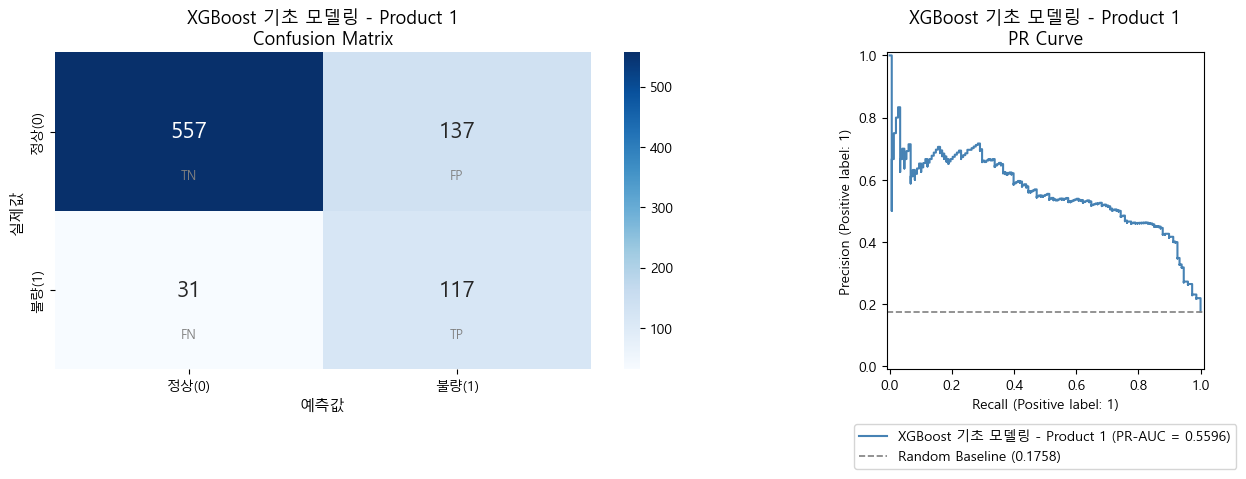

In [28]:
# 3. XGBoost 기초모델링의 성능 평가
evaluate_model(xgb_base_p1,  X_test_p1, y_test_p1, "XGBoost 기초 모델링 - Product 1")

#### 4.2 XGBoost - 개선
- 목표:머신러닝 모델의 파라미터 중 최적의 파라미터를 찾아 성능 개선

In [29]:
# 1. 탐색할 파라미터 후보 정의
xgb_params = {
    "n_estimators"    : [100, 300, 500], # 트리 개수
    "max_depth"       : [3, 5, 7], # 트리 깊이
    "learning_rate"   : [0.05, 0.1], # 학습률
    "subsample"       : [0.8, 1.0], # 트리 학습 시 전체 샘플 중 몇 %를 사용할 것인가?
    "colsample_bytree": [0.8, 1.0], # 트리 학습 시 전체 피쳐 중 몇 %를 사용할 것인가?
    "min_child_weight": [1, 3, 5] # 리프 노드에 최소 몇 개의 샘플이 있어야 하는가?
}

# 2. GridSearchCV 정의
xgb_grid_p1 = GridSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=weights,  # 불균형 보정 (정상/불량 = 4.6937)
        eval_metric="logloss",     # 내부 평가 기준 (이진 분류 표준)
        random_state=42,
        n_jobs=-1
    ),
    param_grid=xgb_params, # 탐색할 파라미터 후보
    scoring="average_precision", # 최적화 기준 : PR-AUC
    cv=cv,     # Stratified K-Fold (K=5)
    n_jobs=-1, # 병렬 처리로 탐색 속도 향상
    verbose=0, # 학습 진행 상황 출력x (전체 진행상황을 출력하고 싶다면 1로 변경)
    refit=True # 찾아낸 최적 파라미터를 사용해 전체 Train 데이터 재학습
)

# 3. 학습
xgb_grid_p1.fit(X_train_p1, y_train_p1)

print("=" * 40)
print("XGBoost GridSearch 진행 종료")
print(f"최적의 파라미터: {xgb_grid_p1.best_params_}")
print(f"CV PR-AUC: {xgb_grid_p1.best_score_:.4f}")
print("=" * 40)

XGBoost GridSearch 진행 종료
최적의 파라미터: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8}
CV PR-AUC: 0.5890



  XGBoost (GridSearchCV 적용) - Product 1

PR-AUC: 0.6924   (Random Baseline: 0.1758)

Classification Report
              precision    recall  f1-score   support

       정상(0)       0.93      0.92      0.92       694
       불량(1)       0.63      0.66      0.64       148

    accuracy                           0.87       842
   macro avg       0.78      0.79      0.78       842
weighted avg       0.87      0.87      0.87       842



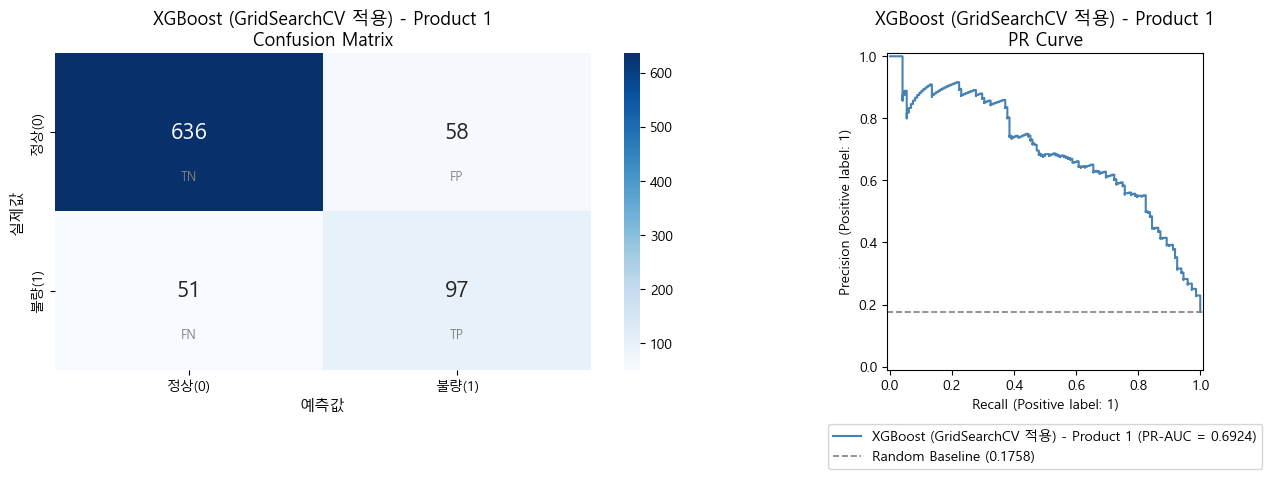

In [30]:
# 4. 성능 평가
evaluate_model(xgb_grid_p1.best_estimator_, X_test_p1, y_test_p1, "XGBoost (GridSearchCV 적용) - Product 1")

---
### **5. 머신러닝 모델 개발(LightGBM)**

#### 5.1 LightGBM - 기초
- 학습율 0.1를 제외하고, LightGBM의 기본 파라미터를 사용해 baseline 확인 

In [31]:
# 1. GridSearch 전 기준점(Baseline) 성능을 확인
lgbm_base_p1 = LGBMClassifier(
    learning_rate=0.1,
    is_unbalance=True, # 불균형한 클래스 비율을 보정(auto)
    random_state=42,
    n_jobs=-1, # 모든 CPU 코어 사용
    verbose=-1 # LightGBM 자체적으로 학습과정을 출력하는 것을 억제
)
# 기본 파라미터 사용
    # n_estimators = 100
    # max_depth = -1 (제한 없음)
    # subsample = 1.0

# 2. Train 데이터로 학습
lgbm_base_p1.fit(X_train_p1, y_train_p1)

print("=" * 30)
print("LightGBM Base 학습 완료!")
print("=" * 30)

LightGBM Base 학습 완료!



  LightGBM 기초 모델링 - Product 1

PR-AUC: 0.6115   (Random Baseline: 0.1758)

Classification Report
              precision    recall  f1-score   support

       정상(0)       0.95      0.87      0.91       694
       불량(1)       0.55      0.78      0.65       148

    accuracy                           0.85       842
   macro avg       0.75      0.82      0.78       842
weighted avg       0.88      0.85      0.86       842



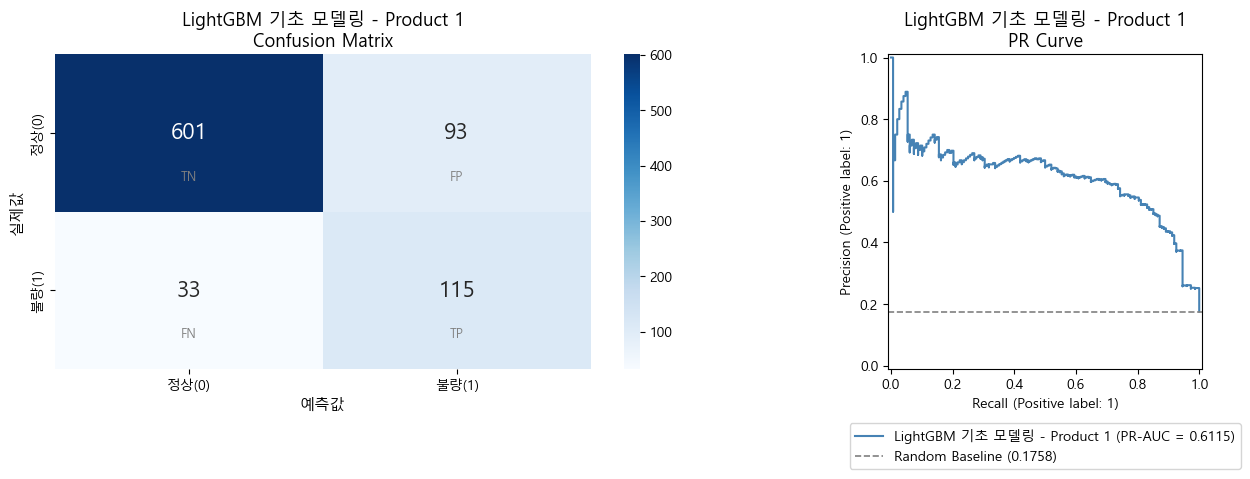

In [32]:
# 3. LightGBM 기초모델링의 성능 평가
evaluate_model(lgbm_base_p1, X_test_p1, y_test_p1, "LightGBM 기초 모델링 - Product 1")

#### 5.2 LightGBM - 개선
- 목적: GridSearch 최적의 파라미터로 성능 개선

In [33]:
# 1. 탐색할 파라미터 후보 정의
lgbm_params = {
    "n_estimators"     : [100, 300, 500], 
    "max_depth"        : [3, 5, 7], 
    "learning_rate"    : [0.05, 0.1],
    "subsample"        : [0.8, 1.0], 
    "colsample_bytree" : [0.8, 1.0], 
    "min_child_samples": [10, 20, 30] # XGBoost의 min_child_weight와 유사하지만 샘플 수 단위를 의미
}

# 2. GridSearchCV 정의
lgbm_grid_p1 = GridSearchCV(
    estimator=LGBMClassifier(
        is_unbalance=True, # 불균형한 클래스 비율을 보정(auto)
        random_state=42,
        n_jobs=-1, # 모델 1개 학습 시 병렬 처리
        verbose=-1 # LightGBM 자체 로그 출력x
    ),
    param_grid=lgbm_params, # 탐색할 파라미터 후보
    scoring="average_precision", # 최적화 기준 : PR-AUC
    cv=cv,
    n_jobs=-1,
    verbose=0, 
    refit=True 
)

# 3. 학습
lgbm_grid_p1.fit(X_train_p1, y_train_p1)

print("=" * 40)
print("LightGBM GridSearch 진행 종료")
print(f"최적의 파라미터: {lgbm_grid_p1.best_params_}")
print(f"CV PR-AUC: {lgbm_grid_p1.best_score_:.4f}")
print("=" * 40)

LightGBM GridSearch 진행 종료
최적의 파라미터: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_samples': 10, 'n_estimators': 500, 'subsample': 0.8}
CV PR-AUC: 0.5976



  LightGBM (GridSearchCV 적용) - Product 1

PR-AUC: 0.6954   (Random Baseline: 0.1758)

Classification Report
              precision    recall  f1-score   support

       정상(0)       0.93      0.92      0.93       694
       불량(1)       0.64      0.69      0.66       148

    accuracy                           0.88       842
   macro avg       0.79      0.80      0.79       842
weighted avg       0.88      0.88      0.88       842



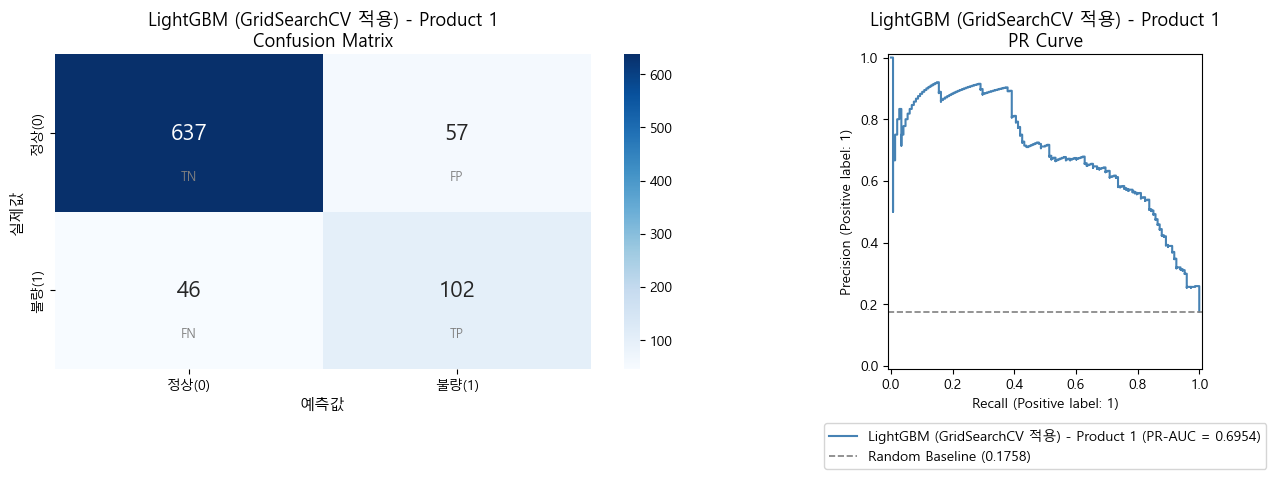

In [34]:
# 4. 성능 평가
evaluate_model(lgbm_grid_p1.best_estimator_, X_test_p1, y_test_p1, "LightGBM (GridSearchCV 적용) - Product 1")

---
### **6. 머신러닝 모델의 성능 정리**

#### 6.1 전체 모델의 불량 기준 Classification_Report 출력

In [35]:
# 성능 지표 비교 테이블

from sklearn.metrics import average_precision_score, classification_report
import pandas as pd

def get_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    pr_auc = average_precision_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    return {
        "PR-AUC": round(pr_auc, 4),
        "불량 Precision": round(report["1"]["precision"], 4),
        "불량 Recall": round(report["1"]["recall"], 4),
        "불량 F1-Score": round(report["1"]["f1-score"], 4),
    }

# 각 모델의 성능 평가 지표 수집
metrics = {
    "XGBoost Base"  : get_metrics(xgb_base_p1, X_test_p1, y_test_p1),
    "LightGBM Base" : get_metrics(lgbm_base_p1, X_test_p1, y_test_p1),
    "XGBoost Grid"  : get_metrics(xgb_grid_p1.best_estimator_, X_test_p1, y_test_p1),
    "LightGBM Grid" : get_metrics(lgbm_grid_p1.best_estimator_, X_test_p1, y_test_p1),
}

# 데이터프레임으로 변환
df_metrics = pd.DataFrame(metrics).T.reset_index()
df_metrics.columns = ["모델", "PR-AUC", "불량 Precision", "불량 Recall", "불량 F1-Score"]

display(df_metrics)

,모델,PR-AUC,불량 Precision,불량 Recall,불량 F1-Score
0,XGBoost Base,0.5596,0.4606,0.7905,0.5821
1,LightGBM Base,0.6115,0.5529,0.7770,0.6461
2,XGBoost Grid,0.6924,0.6258,0.6554,0.6403
3,LightGBM Grid,0.6954,0.6415,0.6892,0.6645


##### 6.1.1 최종 선정된 모델: *LightGBM (GridSearchCV 적용)*
- 전체 모델의 PR-AUC 변화
    - XGBoost: 약 0.56에서 0.692로 향상됨
    - LightGBM: 약 0.612에서 0.0.695로 향상됨
    > 모델의 전체적인 품질이 높은 **LightGBM (GridSearchCV 적용)** 모델을 최종 선정함

- 최종 선정한 모델 성능 분석
    - Precision이 기존보다 향상되어 정상 제품을 불량으로 잘못 판단할 확률이 감소함
    - Recall은 하이퍼파라미터 튜닝 전보다 낮아졌으나 F1-Score는 향상됨
    - PR-AUC: 임계값을 0~1까지 바꿔가면서 전반적인 모델의 성능을 보는 지표
        - 클래스간 비율이 불균형한 데이터에서 모델의 성능을 평가하기 유리한 지표로서, 해당 값을 통해 모델의 전반적인 성능을 평가할 수 있음
        - 하이퍼파라미터 튜닝 후, PR-AUC값이 약 0.08 가량 상승함
        - PR-AUC, Recall, F1-Score 모든 지표에서 전체 모델 중 가장 우수한 성능을 보임

- FP, FN 수치도 확인한 이유
    - 정상인데 불량으로 잘못 분류된 제품은 다시 정상으로 판단하기 위해 비용이 필요하고, 불량인데 정상으로 잘못 분류된 제품이 시장으로 나갔을 때 회사의 브랜드 가치를 떨어뜨릴 수 있기 때문임 


#### 6.2 SHAP 분석
- 목적 : 모델이 왜 이 샘플을 불량이라 예측했는지 각 피쳐의 기여도를 수치로 확인하기 위해서 수행

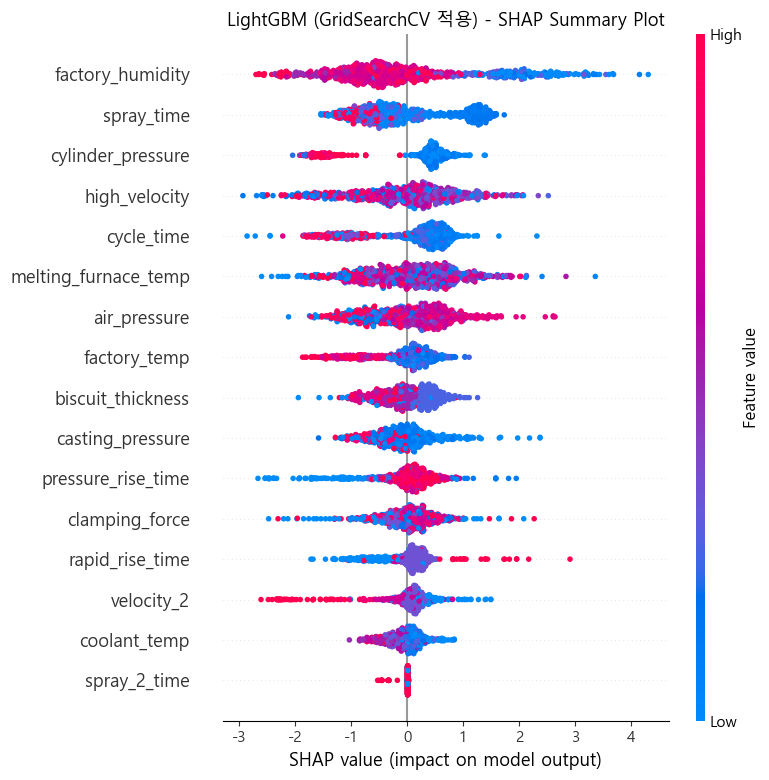

In [36]:
# 1. SHAP Explainer 생성
explainer = shap.TreeExplainer(lgbm_grid_p1.best_estimator_)

# 2. SHAP 값 계산
# 각 샘플의 각 피쳐가 예측에 얼마나 기여했는지 수치로 계산
shap_values = explainer.shap_values(X_test_p1)

# 3. SHAP Summary Plot
# - 피쳐 값이 높을 때(빨간색) / 낮을 때(파란색) 불량 확률에 어떤 영향을 주는지 표시
# - 오른쪽(+) : 불량 확률 높임 / 왼쪽(-) : 불량 확률 낮춤
# - 위에 있을수록 예측에 영향을 많이 준 피쳐
plt.figure(facecolor='none')
shap.summary_plot(
    shap_values, X_test_p1,
    show=False
)
plt.title("LightGBM (GridSearchCV 적용) - SHAP Summary Plot", fontsize=13)
plt.tight_layout()
plt.show()

##### 6.2.1 SHAP 해석
(1) 제품유형 1에서 상위 5개 피쳐 (feature)
 - `factory_humidity`
    - 습도가 높을수록 불량인 제품을 생산할 확률이 낮아지는 경향을 보임
 - `cylinder_pressure`
    - 실린더 압력이 낮을수록 불량인 제품을 생산할 확률이 높아짐
 - `air_pressure`
    - 값이 높을수록 불량인 제품을 생산할 확률이 높아짐
 - `high_velocity`
    - Mann-Whitney U 검정에서는 효과크기가 0.1 이하로 매우 작게 나왔으나 다른 변수들과 조합해서 관찰해보니 피쳐의 영향력이 높아진 것으로 보임
    - 모든 방향에서 빨간색과 파란색이 혼재되어 있어 단순히 어떤 크기를 가졌다고 불량인 제품을 생산할 확률이 어떻게 변하는지 언급하기는 어려운 지표일 것으로 사료됨
 - `spray_time`
    - spray 분사 시간이 짧을수록 불량인 제품을 생산할 확률이 높아짐 

(2) 두 제품 유형에서 모두 불량에 영향을 주는 요소: `high_velocity`
 - 제품 유형 1에서는 수치의 크기가 불량에 큰 영향을 주지 않고, 크기가 불량에 영향을 주는 것도 모호한 측면이 있음
 - 제품 유형 2에서는 high_velocity의 값이 클수록 불량 제품을 생산할 확률이 낮아진다는 것을 명확하게 확인할 수 있음 

---
### **7. 모델링한 파일 저장**
- 기초 파라미터를 이용해 만든 모델과 최적의 파라미터를 찾아 만든 모델을 모두 저장함
- 저장된 모델 목록
    - XGBoost 기초 모델
    - LightGBM 기초 모델
    - XGBoost GridSearch 모델
    - LightGBM GridSearch 모델

In [37]:
# 저장 폴더 생성 (없으면 자동 생성)
os.makedirs('../models', exist_ok=True)

# 1. XGBoost 기초 모델 저장
joblib.dump(xgb_base_p1, '../models/XGBoost_기초_모델_product-1.pkl')
print("XGBoost Base 모델 저장 완료")

# 2. LightGBM 기초 모델 저장
joblib.dump(lgbm_base_p1, '../models/LightGBM_기초_모델_product-1.pkl')
print("LightGBM Base 모델 저장 완료")

# 3. XGBoost GridSearch 모델 저장
joblib.dump(xgb_grid_p1.best_estimator_, '../models/XGBoost_개선_모델_product-1.pkl')
print("XGBoost GridSearch 모델 저장 완료")

# 4. LightGBM GridSearch 모델 저장
joblib.dump(lgbm_grid_p1.best_estimator_, '../models/LightGBM_개선_모델_product-1.pkl')
print("LightGBM GridSearch 모델 저장 완료")

XGBoost Base 모델 저장 완료
LightGBM Base 모델 저장 완료
XGBoost GridSearch 모델 저장 완료
LightGBM GridSearch 모델 저장 완료
